# Raducan Ana Maria S5797859
# Classificazione del valore delle case in California

---

## 1. Caricamento dati

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=3)

In [2]:
# Caricamento CSV data
csv_path = 'houses_data.csv'
df = pd.read_csv(csv_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco,median_house_value
0,-121.48,38.58,42.0,1823.0,566.0,761.0,503.0,1.2450,56605.775179,580889.416012,759695.004208,143043.151608,122257.998578,1
1,-118.16,33.96,24.0,1635.0,507.0,2480.0,481.0,2.4432,23275.681574,12833.107273,166591.203013,504538.443854,572564.270481,2
2,-116.41,33.74,17.0,4289.0,893.0,958.0,440.0,2.4659,109783.652563,172765.858404,133611.248886,636951.380308,704278.553944,2
3,-118.28,33.92,39.0,1274.0,282.0,975.0,277.0,1.5114,12482.064427,15080.299933,169527.675887,500778.155643,568764.984549,0
4,-118.20,33.96,41.0,1512.0,400.0,1690.0,367.0,3.0550,21094.938610,11018.189002,168689.069801,502131.598805,570150.638590,2


In [3]:
#tipi delle variabili, valori mancanti, statistiche descrittive
print(df.dtypes)

longitude                   float64
latitude                    float64
housing_median_age          float64
total_rooms                 float64
total_bedrooms              float64
population                  float64
households                  float64
median_income               float64
distance_to_coast           float64
distance_to_la              float64
distance_to_sandiego        float64
distance_to_sanjose         float64
distance_to_sanfrancisco    float64
median_house_value            int64
dtype: object


### Domande

**Quali variabili sono categoriali e quali numeriche?**

Osservando i tipi delle colonne ottenuti grazie a df.dtypes, noto che ci sono 13 attributi di tipo float, quindi numerici. L'unico di tipo diverso è median_house_value, che è di tipo int, ma si tratta comunque di una variabile categoriale perchè grazie al PDF del progetto so infatti che i valori 0, 1, 2, 3, 4 non sono prezzi veri ma 5 etichette che corrispondono a 5 fasce di prezzo

In [4]:
#Separazione di features (X) e target (y)
y = df['median_house_value']
X = df.drop(columns=['median_house_value'])

print('\nFeature names:', list(X.columns))


Feature names: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'distance_to_coast', 'distance_to_la', 'distance_to_sandiego', 'distance_to_sanjose', 'distance_to_sanfrancisco']


---

## 2. Visualizzazione dei dati

In [5]:
# Gestione dei valori mancanti
df = df.dropna()
y = df['median_house_value']
X = df.drop(columns=['median_house_value'])
print(X.shape, y.shape)

(10222, 13) (10222,)


In [6]:
# Bilanciamento delle classi
y.value_counts().sort_index()

median_house_value
0    2003
1    2068
2    2050
3    2088
4    2013
Name: count, dtype: int64

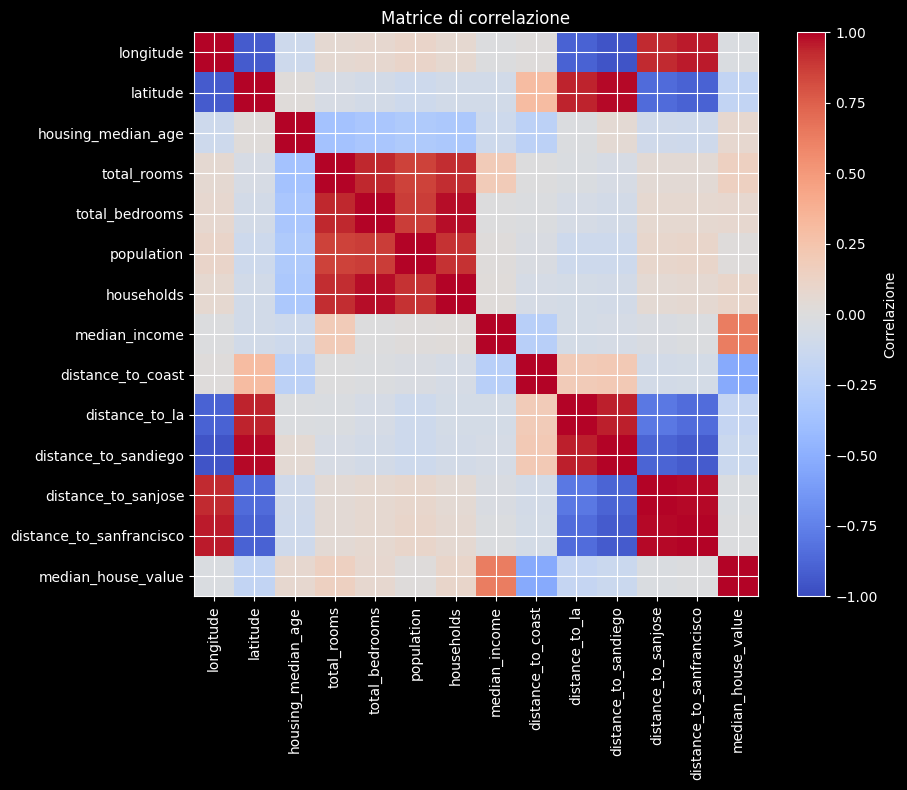

distance_to_coast          -0.530162
latitude                   -0.184351
distance_to_la             -0.167283
distance_to_sandiego       -0.128352
longitude                  -0.025434
distance_to_sanjose        -0.023671
distance_to_sanfrancisco   -0.010072
population                  0.013707
total_bedrooms              0.075369
housing_median_age          0.077108
households                  0.094807
total_rooms                 0.145207
median_income               0.625879
median_house_value          1.000000
Name: median_house_value, dtype: float64

In [7]:
#Correlazioni
df.corr()['median_house_value'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
plt.imshow(df.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlazione')
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

#Correlazione col target
df.corr()['median_house_value'].sort_values()

### Domande

**Ci sono valori mancanti? Quanti e su quali variabili? Come li puoi gestire?**
Sì, ci sono 98 valori mancanti tutti nella colonna total_bedrooms. Le altre colonne sono complete. Visto che sono meno dell'1% del dataset, li elimino con dropna() come fatto nel Lab 1. Dopo la pulizia restano 10222 righe.

**Il target richiede regressione o classificazione? In quante classi? Le classi sono bilanciate?**
È un problema di classificazione, perché `median_house_value` non è un prezzo vero ma una delle 5 fasce di prezzo (0, 1, 2, 3, 4) descritte nel PDF.
Sono 5 le classi.
Le classi sono bilanciate, ogni classe ha circa 2000 campioni (tra 2003 e 2088), quindi sono tutte rappresentate quasi allo stesso modo.

**Esistono correlazioni tra le variabili e il target e tra le variabili stesse? Formula ipotesi e verifica.**
Guardando le correlazioni col prezzo (`median_house_value`):
- `median_income` ha correlazione +0.626. È il valore più alto quindi il reddito è la variabile più legata al prezzo.
- `distance_to_coast` ha correlazione -0.530. Il segno negativo significa che più ci si allontana dalla costa più i prezzi scendono.
- Tutte le altre variabili hanno valori vicini a 0, quindi da sole non aiutano molto a prevedere il prezzo.

---

## 3. Codifica della variabile target


Per ogni algoritmo, la codifica più appropriata è:
- ERM con loss quadratica: per gestire 5 classi usiamo la strategia one-vs-rest. Questo algoritmo nella sua forma base sa distinguere solo tra due classi, quindi alleniamo 5 versioni dell'algoritmo, una per ogni classe. Ogni versione impara a riconoscere "è questa classe" oppure "non è questa classe". Alla fine, per ogni casa, guardiamo quale delle 5 versioni è più sicura della sua risposta, e scegliamo quella classe.
- Regressione logistica: qui non serve costruire a mano i 5 classificatori uno contro tutti. Uso LogisticRegression una classe già pronta di scikit-learn, che gestisce da sola il caso con più classi. Si passa y con i valori 0-4 e si occupa lei di tutto internamente.
- k-NN: gestisce le 5 classi senza bisogno di one-vs-rest. Per ogni casa da classificare, guarda le k case più simili nel training set e le assegna la classe più comune tra quelle.
- Alberi decisionali: gestiscono il multi-classe in modo nativo, ogni foglia assegna direttamente una delle 5 classi.

---
## 4. Cross validation
Per valutare i modelli divido il dataset in due parti, come nel Lab 2.
L'80% dei dati (8177 case) va nel training set che uso per addestrare i modelli.
Il restante 20% (2045 case) va nel test set che tengo da parte e uso solo alla fine per vedere come va il mio modello migliore su dati mai visti.

Quando addestro gli algoritmi nei punti successivi userò anche la cross validation. Divido il training in 5 parti e provo il modello su una parte alla volta, così posso scegliere i parametri migliori senza toccare il test.
Uso `random_state=123` così la divisione viene sempre uguale.

In [8]:
# Cross validation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (8177, 13)
Test set: (2045, 13)


---
## 5. Classificazione tramite minimizzazione del rischio empirico con loss quadratica
- Esegui il fit
- Interpreta i coefficienti ottenuti
- Valuta le prestazioni


In [9]:
#Classificazione con loss quadratica
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier

# Standardizzazione delle feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = RidgeClassifier(random_state=123)
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details.",123


In [10]:
#una riga per ogni classe e una colonna per ogni feature
coef_df = pd.DataFrame(ridge.coef_, columns=X.columns, index=[f'classe {i}' for i in range(5)])
coef_df.round(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco
classe 0,0.235,-0.857,0.064,0.017,-0.243,0.063,0.127,-0.200,0.374,0.172,1.200,-0.144,0.393
classe 1,0.297,1.346,-0.039,-0.038,0.112,0.258,-0.329,-0.165,-0.162,0.194,-1.382,0.034,-0.227
classe 2,-0.033,0.757,-0.078,-0.064,0.092,0.135,-0.179,-0.075,-0.171,-0.048,-0.898,0.099,-0.225
classe 3,-0.249,-0.390,-0.035,0.091,-0.098,-0.135,0.184,0.021,-0.085,-0.133,0.284,-0.250,0.274
classe 4,-0.250,-0.856,0.089,-0.006,0.137,-0.322,0.196,0.419,0.044,-0.186,0.795,0.261,-0.215


Guardando la tabella dei coefficienti, median_income ha valori che salgono da -0.200 (classe 0) a +0.419 (classe 4): più reddito nella zona, più il modello pensa che la casa sia in una fascia di prezzo alta. Anche distance_to_coast aiuta a capire: è positivo per la classe 0 (+0.374) e negativo per le altre classi, quindi le case lontane dalla costa vengono messe più spesso nella classe più economica. Sono le stesse due variabili che al punto 2 avevano la correlazione più alta col prezzo

In [11]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5)
print('Accuracy nei 5 fold:', cv_scores.round(3))
print('Media:', cv_scores.mean().round(3))

Accuracy nei 5 fold: [0.513 0.496 0.492 0.481 0.494]
Media: 0.495


In [12]:
test_accuracy = ridge.score(X_test_scaled, y_test)
print('Accuracy sul test set:', round(test_accuracy, 3))

Accuracy sul test set: 0.496



Prestazioni: l'accuracy in cross validation (0.495) e sul test set (0.496) sono quasi identiche, quindi niente overfitting. Però il modello indovina solo metà delle volte

---
## 6. Classificazione tramite minimizzazione del rischio empirico con loss logistica
- Esegui il fit
- Analizza l’effetto del parametro di regolarizzazione
- Quali classi sono piu difficili da predire?


In [13]:
# Classificazione con loss logistica
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=123, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

test_accuracy = logreg.score(X_test_scaled, y_test)
print('Accuracy sul test set:', round(test_accuracy, 3))

Accuracy sul test set: 0.562


In [14]:
# Effetto del parametro di regolarizzazione C con cross validation
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, random_state=123, max_iter=1000)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f'C={C}: accuracy media CV = {round(scores.mean(), 3)}')

C=0.01: accuracy media CV = 0.536
C=0.1: accuracy media CV = 0.555
C=1: accuracy media CV = 0.562
C=10: accuracy media CV = 0.565
C=100: accuracy media CV = 0.567


Il parametro C controlla quanto il modello viene "limitato": C piccolo = più regolarizzazione (modello più semplice), C grande = meno regolarizzazione (modello più libero). Nei risultati l'accuracy sale man mano che C aumenta, da 0.536 (C=0.01) a 0.567 (C=100). Quindi meno regolarizzazione aiuta: il modello non si sta adattando troppo ai dati di training, anzi può ancora imparare un po' di più dai dati. Per questo scegliamo C=100.

In [15]:
# Modello finale C scelto tramite cross validation (C=100)
best_logreg = LogisticRegression(C=100, random_state=123, max_iter=1000)
best_logreg.fit(X_train_scaled, y_train)
test_accuracy = best_logreg.score(X_test_scaled, y_test)
print('Accuracy sul test set (C=100):', round(test_accuracy, 3))

Accuracy sul test set (C=100): 0.569


In [16]:
from sklearn.metrics import confusion_matrix

y_pred = best_logreg.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[304 107  14   9   1]
 [ 69 202  96  25   6]
 [ 17  84 152 129  15]
 [  3  30  82 204  95]
 [  0   5  20  74 302]]


Quali classi sono più difficili? Guardando la confusion matrix (riga = classe vera, colonna = classe predetta dal modello), le classi 0 e 4 (le più economiche e le più costose) sono predette bene: 304 su 435 corrette per la classe 0, e 302 su 401 corrette per la classe 4. Le classi centrali 1, 2, 3, soprattutto la classe 2, sono le più difficili: vengono spesso confuse con le classi vicine. Le case di fascia di prezzo intermedia hanno caratteristiche più simili tra loro, mentre le case molto economiche o molto costose hanno tratti più distintivi.

---
## 7. k-NN
- Esegui il fit
- Studia l’errore al variare di k valutando se esiste un valore ottimale
- Commenta complessita e accuratezza

In [17]:
# k-NN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

test_accuracy = knn.score(X_test_scaled, y_test)
print('Accuracy sul test set (k=5):', round(test_accuracy, 3))

Accuracy sul test set (k=5): 0.567


In [18]:
# Errore al variare di k con cross validation
k_values = range(1, 21)
cv_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_accuracies.append(scores.mean())
    print(f'k={k}: accuracy media CV = {round(scores.mean(), 3)}')

k=1: accuracy media CV = 0.526
k=2: accuracy media CV = 0.516
k=3: accuracy media CV = 0.535
k=4: accuracy media CV = 0.546
k=5: accuracy media CV = 0.559
k=6: accuracy media CV = 0.557
k=7: accuracy media CV = 0.562
k=8: accuracy media CV = 0.559
k=9: accuracy media CV = 0.558
k=10: accuracy media CV = 0.563
k=11: accuracy media CV = 0.566
k=12: accuracy media CV = 0.566
k=13: accuracy media CV = 0.567
k=14: accuracy media CV = 0.565
k=15: accuracy media CV = 0.568
k=16: accuracy media CV = 0.567
k=17: accuracy media CV = 0.566
k=18: accuracy media CV = 0.567
k=19: accuracy media CV = 0.564
k=20: accuracy media CV = 0.565


In [19]:
#  k scelto tramite cross validation (k=15)
best_knn = KNeighborsClassifier(n_neighbors=15)
best_knn.fit(X_train_scaled, y_train)
test_accuracy = best_knn.score(X_test_scaled, y_test)
print('Accuracy sul test set (k=15):', round(test_accuracy, 3))

Accuracy sul test set (k=15): 0.576


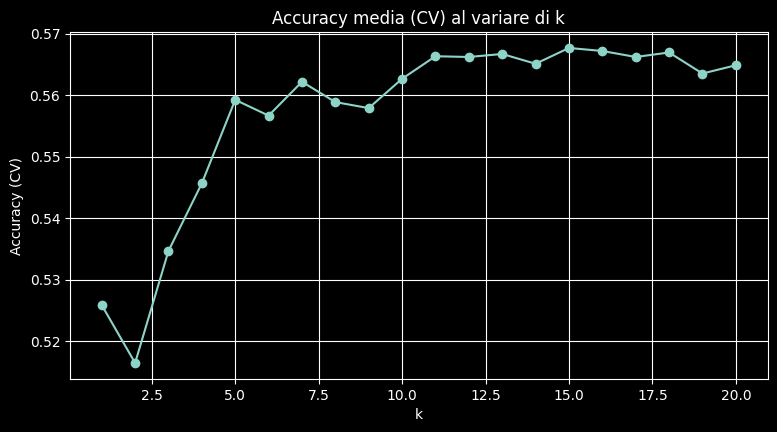

In [20]:
import matplotlib.pyplot as plt

plt.plot(k_values, cv_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy (CV)')
plt.title('Accuracy media (CV) al variare di k')
plt.show()

- Errore al variare di k: con k piccolo (1-4) l'accuracy in CV è bassa (0.526-0.546), perché il modello guarda pochi vicini e può farsi influenzare da casi anomali. Aumentando k l'accuracy sale e si stabilizza intorno a 0.56-0.57 da k=5 in poi, con un picco a k=15 (0.568). Sul test set, il modello con k=15 ottiene un'accuracy di 0.576.
- Complessità: k-NN è semplice. Il fit non fa praticamente nulla, salva solo i dati. Ma quando devi fare una previsione, deve calcolare la distanza da quel punto a tutti i punti del training set, quindi è lento se i dati sono tanti.
- Accuratezza: k-NN (0.576) è leggermente meglio della regressione logistica (0.569) e molto meglio della loss quadratica (0.496).

---
## 8. Alberi decisionali
- Analizza l’effetto dei parametri dell’albero (ad esempio profondita
massima, numero minimo di campioni per foglia) sulle prestazioni del modello.

In [21]:
# Alberi decisionali
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=123)
tree.fit(X_train, y_train)

test_accuracy = tree.score(X_test, y_test)
print('Accuracy sul test set (default):', round(test_accuracy, 3))

Accuracy sul test set (default): 0.573


In [22]:
# Effetto della profondità massima con cross validation
for depth in [2, 3, 5, 10, 15, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=123)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f'max_depth={depth}: accuracy media CV = {round(scores.mean(), 3)}')

max_depth=2: accuracy media CV = 0.407
max_depth=3: accuracy media CV = 0.445
max_depth=5: accuracy media CV = 0.5
max_depth=10: accuracy media CV = 0.577
max_depth=15: accuracy media CV = 0.57
max_depth=None: accuracy media CV = 0.563


In [23]:
# Effetto del numero minimo di campioni per foglia con cross validation
for leaf in [1, 5, 10, 20, 50, 100]:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=123)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f'min_samples_leaf={leaf}: accuracy media CV = {round(scores.mean(), 3)}')

min_samples_leaf=1: accuracy media CV = 0.563
min_samples_leaf=5: accuracy media CV = 0.573
min_samples_leaf=10: accuracy media CV = 0.581
min_samples_leaf=20: accuracy media CV = 0.589
min_samples_leaf=50: accuracy media CV = 0.568
min_samples_leaf=100: accuracy media CV = 0.543


In [24]:
# CV sul modello finale max_depth=10 + min_samples_leaf=20
model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=123)
scores = cross_val_score(model, X_train, y_train, cv=5)
print('Accuracy nei 5 fold:', scores.round(3))
print('Media CV:', round(scores.mean(), 3))

Accuracy nei 5 fold: [0.59  0.583 0.592 0.575 0.569]
Media CV: 0.582


Effetto dei parametri: se max_depth è troppo basso (2-3), l'albero è troppo semplice e indovina poco (0.407-0.445). Aumentando arriva a un massimo a max_depth=10 (0.577). Stessa cosa per min_samples_leaf: con leaf=1 l'accuracy è bassa (0.563), il massimo è a leaf=20 (0.589). Usando insieme max_depth=10 e min_samples_leaf=20, il modello ottiene 0.582 di accuracy media in CV, confermato poi a 0.587 sul test set.

In [25]:
best_tree = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=123)
best_tree.fit(X_train, y_train)
test_accuracy = best_tree.score(X_test, y_test)
print('Accuracy sul test set (max_depth=10, min_samples_leaf=20):', round(test_accuracy, 3))

Accuracy sul test set (max_depth=10, min_samples_leaf=20): 0.587


In [26]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
7,median_income,0.336725
8,distance_to_coast,0.293292
0,longitude,0.068754
1,latitude,0.068246
9,distance_to_la,0.052707
12,distance_to_sanfrancisco,0.051570
11,distance_to_sanjose,0.040874
10,distance_to_sandiego,0.028800
2,housing_median_age,0.022470
3,total_rooms,0.015477


- Quali variabili risultano più importanti secondo il modello? Secondo feature_importances_, le variabili più importanti sono median_income (0.337) e distance_to_coast (0.293), che insieme rappresentano più del 60% dell'importanza totale. Seguono longitude (0.069) e latitude (0.068). Le altre variabili hanno importanza molto più bassa.
- I risultati sono coerenti con l'analisi delle correlazioni? Sì. Al punto 2 avevamo trovato che median_income era tra le variabili più correlate con median_house_value, e così anche le variabili legate alla posizione geografica (distanza dalla costa, longitude, latitude). Il fatto che l'albero le scelga come le più importanti conferma quello che si era già osservato, ovvero che il prezzo delle case dipende soprattutto dal reddito della zona e da quanto è vicina alla costa/alle grandi città.

---
## 10.
Provando 4 modelli diversi per prevedere la fascia di prezzo delle case, quello che ha funzionato meglio è l'albero decisionale, con un'accuracy media in cross validation di 0.582 (usando max_depth=10 e min_samples_leaf=20, scelti tramite cross validation), confermata poi a 0.587 sul test set. Gli altri modelli sono andati peggio, sempre guardando la cross validation: k-NN 0.568 (k=15), regressione logistica 0.567 (C=100), e il peggiore è stato la loss quadratica con one-vs-rest, con solo 0.495. L'albero probabilmente ha funzionato meglio perché riesce a "dividere" i dati in tanti piccoli gruppi seguendo regole semplici (tipo "se il reddito è alto e la casa è vicina alla costa, allora..."), mentre la loss quadratica e la logistica cercano relazioni più semplici (lineari) tra le variabili e il prezzo, che probabilmente non bastano per questo problema. In tutti i modelli, le classi centrali (1, 2, 3, soprattutto la 2) sono risultate le più difficili da prevedere, perché le case di prezzo "medio" si assomigliano di più tra loro. Invece le case molto economiche (classe 0) o molto costose (classe 4) sono più facili da riconoscere. Le variabili più utili per prevedere il prezzo sono risultate median_income (reddito della zona) e distance_to_coast (distanza dalla costa), che insieme rappresentano più del 60% dell'importanza secondo l'albero, ed erano anche le variabili più correlate al prezzo trovate nel punto 2. Per il modello finale è stato scelto l'albero decisionale con max_depth=10 e min_samples_leaf=20, perché è quello con l'accuracy media più alta in cross validation sul training set (0.582); il risultato è stato poi confermato sul test set (0.587), usato solo per questa verifica finale.